## Pypsa to model Ghana's 2024 power system and test contingencies


Ghana 2024 Power System — Baseline Dispatch
============================================
Vanilla PyPSA single-node model.
Real generator fleet from Energy Commission Statistical Bulletin.
Real hourly demand profile constructed from WEM Bulletins.
Marginal costs: heat_rate x fuel_price / 1000 (USD/MWh).
Validation targets from Statistical Bulletin 2025 .
 
Author:  Engr. Kwaku Duah


In [1]:
import pypsa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings("ignore")

In [2]:
# paths

DEMAND_PATH    = "/data/Pypsa-Research/data/demand/Ghana_2024_Hourly_Demand_MW.csv"
FLEET_PATH     = "/data/Pypsa-Research/data/generators/ghana_fleet_2024.csv"
RESULTS_PATH   = "/data/Pypsa-Research/results/"

In [3]:
# Demand/ Load Profile
demand = pd.read_csv(DEMAND_PATH, index_col=0, parse_dates=True)
demand.index.name = "snapshot"

In [4]:
# Drop leap day as 2024 was a leap year - standardizing to 8760 hours

demand = demand[~((demand.index.month == 2) & (demand.index.day == 29))]
assert len(demand) == 8760, f"Expected 8760 hours, got {len(demand)}"
print(f"Demand loaded: {len(demand)} hours")
print(f"  Peak:    {demand['demand_MW'].max():.1f} MW  (reference: 3,659.7 MW)")
print(f"  Average: {demand['demand_MW'].mean():.1f} MW")
print(f"  Annual:  {demand['demand_MW'].sum()/1000:.1f} GWh  (reference: 20,303 GWh)")

Demand loaded: 8760 hours
  Peak:    3659.7 MW  (reference: 3,659.7 MW)
  Average: 2297.7 MW
  Annual:  20127.5 GWh  (reference: 20,303 GWh)


In [5]:
# Initialise network
n = pypsa.Network(name="Ghana-network-2024")


In [6]:
# Set snapshots
n.set_snapshots(demand.index)

In [7]:
# Attach bus - Ghana only/domestic system excluding exports

n.add("Bus", "Ghana", carrier="AC", unit="MW")
 
# Attach load
n.add("Load", "Ghana_load",
      bus="Ghana",
      p_set=demand["demand_MW"])

In [8]:
# Add generator fleet

fleet = pd.read_csv(FLEET_PATH, comment="#")
fleet.columns = fleet.columns.str.strip()

# Parse numeric columns
numeric_cols = ["p_nom_mw", "marginal_cost_usd_mwh", "capital_cost", "p_max_pu"]
fleet[numeric_cols] = fleet[numeric_cols].apply(pd.to_numeric, errors="coerce")

# Drop any rows where p_nom_mw is NaN (blank spacer rows in CSV)
fleet = fleet.dropna(subset=["p_nom_mw"])

print(fleet[["name", "carrier", "p_nom_mw", "marginal_cost_usd_mwh", "p_max_pu"]])

                  name           carrier  p_nom_mw  marginal_cost_usd_mwh  \
2             Akosombo             hydro    1020.0                   0.00   
3                Kpong             hydro     160.0                   0.00   
4                  Bui             hydro     404.0                   0.00   
5            Bui_Solar             solar      55.0                   0.00   
6      VRA_Kaleo_Solar             solar      29.0                   0.00   
7   VRA_Navrongo_Solar             solar       2.5                   0.00   
8      VRA_Lawra_Solar             solar       6.5                   0.00   
9            BXC_Solar             solar      20.0                   0.00   
10      Meinergy_Solar             solar      20.0                   0.00   
11               TAPCO               gas     330.0                  65.57   
12                TICO               gas     340.0                 117.30   
13                SAPP               gas     560.0                  65.14   

In [9]:
for _, row in fleet.iterrows():
    n.add(
        "Generator",
        row["name"],
        bus="Ghana",
        carrier=row["carrier"],
        p_nom=row["p_nom_mw"],
        marginal_cost=row["marginal_cost_usd_mwh"],
        capital_cost=row["capital_cost"],
        p_max_pu=row["p_max_pu"],
    )

In [10]:
print(f"\nFleet loaded: {len(n.generators)} generators")
print(f"  Total installed capacity: {n.generators.p_nom.sum():.1f} MW")
print(f"  (Reference Table 3.2:    5,749 MW)")


Fleet loaded: 26 generators
  Total installed capacity: 5936.1 MW
  (Reference Table 3.2:    5,749 MW)


In [11]:
print("\nRunning dispatch optimisation...")
status, condition = n.optimize(solver_name="highs")
print(f"  Status: {status} | {condition}")

Index(['Akosombo', 'Kpong', 'Bui', 'Bui_Solar', 'VRA_Kaleo_Solar',
       'VRA_Navrongo_Solar', 'VRA_Lawra_Solar', 'BXC_Solar', 'Meinergy_Solar',
       'TAPCO', 'TICO', 'SAPP', 'TT1PP', 'TT2PP', 'CENIT', 'Karpower', 'AMERI',
       'Twin_City', 'Cenpower', 'AKSA', 'KTPP', 'Early_Power', 'Genser',
       'Bridge_Power', 'Takoradi_T3', 'Safisana'],
      dtype='object', name='Generator')
Index(['Ghana'], dtype='object', name='Bus')



Running dispatch optimisation...


Index(['Akosombo', 'Kpong', 'Bui', 'Bui_Solar', 'VRA_Kaleo_Solar',
       'VRA_Navrongo_Solar', 'VRA_Lawra_Solar', 'BXC_Solar', 'Meinergy_Solar',
       'TAPCO', 'TICO', 'SAPP', 'TT1PP', 'TT2PP', 'CENIT', 'Karpower', 'AMERI',
       'Twin_City', 'Cenpower', 'AKSA', 'KTPP', 'Early_Power', 'Genser',
       'Bridge_Power', 'Takoradi_T3', 'Safisana'],
      dtype='object', name='Generator')
Index(['Ghana'], dtype='object', name='Bus')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 1/1 [00:00<00:00,  2.46it/s]
INFO:linopy.io: Writing time: 2.99s


Running HiGHS 1.11.0 (git hash: n/a): Copyright (c) 2025 HiGHS under MIT licence terms
LP   linopy-problem-3rjlfoz3 has 464280 rows; 227760 cols; 683280 nonzeros
Coefficient ranges:
  Matrix [1e+00, 1e+00]
  Cost   [1e+01, 1e+02]
  Bound  [0e+00, 0e+00]
  RHS    [1e-01, 4e+03]
Presolving model
8760 rows, 210240 cols, 210240 nonzeros  0s
8760 rows, 131400 cols, 131400 nonzeros  0s
Dependent equations search running on 6628 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
6628 rows, 99420 cols, 99420 nonzeros  0s
Presolve : Reductions: rows 6628(-457652); columns 99420(-128340); elements 99420(-583860)
Solving the presolved LP
Using EKK dual simplex solver - serial
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Pr: 6628(1.68311e+07) 1s
       6628     3.4685921520e+08 Pr: 0(0) 1s
Solving the original LP from the solution after postsolve
Model name          : linopy-proble

INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 227760 primals, 464280 duals
Objective: 3.47e+08
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper were not assigned to the network.


  Status: ok | optimal


In [12]:
print("\n── RESULTS ────────────────────────────────────────────────────────")
 
# Total system cost
total_cost = n.objective / 1e6
print(f"Total system cost:  USD {total_cost:.2f} million")
 
# Annual generation by carrier
gen_by_carrier = (
    n.generators_t.p
    .sum()
    .groupby(n.generators.carrier)
    .sum()
    / 1000  # GWh
)
total_gen = gen_by_carrier.sum()
print(f"\nAnnual generation by carrier (GWh):")
for carrier, gwh in gen_by_carrier.items():
    share = gwh / total_gen * 100
    print(f"  {carrier:<10}: {gwh:>8.1f} GWh  ({share:.1f}%)")
print(f"  {'TOTAL':<10}: {total_gen:>8.1f} GWh")


── RESULTS ────────────────────────────────────────────────────────
Total system cost:  USD 346.86 million

Annual generation by carrier (GWh):
             hydro:   3539.0 GWh  (17.6%)
           hydro:   1401.6 GWh  (7.0%)
           solar:    657.0 GWh  (3.3%)
          gas:   1327.5 GWh  (6.6%)
         gas:    224.0 GWh  (1.1%)
        gas :     48.0 GWh  (0.2%)
        hydro:   8570.9 GWh  (42.6%)
      gas   :   2825.8 GWh  (14.0%)
      solar :    175.2 GWh  (0.9%)
     gas    :   1022.3 GWh  (5.1%)
     solar  :    311.0 GWh  (1.5%)
    biogas  :      0.7 GWh  (0.0%)
   gas      :      2.6 GWh  (0.0%)
  gas       :      0.0 GWh  (0.0%)
  solar     :     21.9 GWh  (0.1%)
  TOTAL     :  20127.5 GWh


In [13]:
# Validation against Statistical Bulletin 2025
print(f"\n── VALIDATION ─────────────────────────────────────────────────────")
ref_shares = {"hydro": 39.0, "gas": 60.3, "solar": 0.71}
model_shares = (gen_by_carrier / total_gen * 100).to_dict()
print(f"{'Carrier':<10} {'Model %':>10} {'Bulletin %':>12} {'Diff':>8}")
print("-" * 45)
for carrier in ["hydro", "gas", "solar"]:
    model_pct  = model_shares.get(carrier, 0)
    ref_pct    = ref_shares.get(carrier, 0)
    diff       = model_pct - ref_pct
    print(f"{carrier:<10} {model_pct:>10.1f} {ref_pct:>12.1f} {diff:>+8.1f}")
 
# Peak demand check
total_load = n.loads_t.p.sum(axis=1)
print(f"\nPeak demand:  {total_load.max():.1f} MW  (reference: 3,659.7 MW)")


── VALIDATION ─────────────────────────────────────────────────────
Carrier       Model %   Bulletin %     Diff
---------------------------------------------
hydro             0.0         39.0    -39.0
gas               0.0         60.3    -60.3
solar             0.1          0.7     -0.6

Peak demand:  3659.7 MW  (reference: 3,659.7 MW)


In [14]:
# Unmet demand check
gen_total_hourly = n.generators_t.p.sum(axis=1)
unmet = (total_load - gen_total_hourly).clip(lower=0)
print(f"Unmet demand hours: {(unmet > 1).sum()} hours")
print(f"Max unmet demand:   {unmet.max():.2f} MW")

Unmet demand hours: 0 hours
Max unmet demand:   0.00 MW


In [15]:
# CO2 emission intensities (tCO2/MWh_thermal)
# Source: IPCC default emission factors
co2_intensity = {
    "hydro":   0.000,
    "solar":   0.000,
    "gas":     0.202,   # natural gas
    "biogas":  0.000,   # considered carbon neutral
}
 

In [16]:
# ── 6. EMISSIONS ───────────────────────────────────────────────────────────
total_co2 = 0.0
for gen in n.generators.index:
    carrier  = n.generators.loc[gen, "carrier"]
    intensity = co2_intensity.get(carrier, 0)
    gen_gwh  = n.generators_t.p[gen].sum() / 1000
    total_co2 += gen_gwh * intensity * 1000  # tCO2
 
grid_ef = total_co2 / (total_gen * 1000)   # tCO2/MWh
print(f"\nTotal CO2 emissions: {total_co2/1e6:.3f} MtCO2")
print(f"Grid emission factor: {grid_ef:.3f} tCO2/MWh  (reference: 0.35 tCO2/MWh)")


Total CO2 emissions: 0.000 MtCO2
Grid emission factor: 0.000 tCO2/MWh  (reference: 0.35 tCO2/MWh)


In [17]:
# ── 7. MERIT ORDER ─────────────────────────────────────────────────────────
merit = (
    n.generators[["carrier", "p_nom", "marginal_cost"]]
    .sort_values("marginal_cost")
)
print(f"\n── MERIT ORDER ────────────────────────────────────────────────────")
print(merit.to_string())


── MERIT ORDER ────────────────────────────────────────────────────
attribute                    carrier   p_nom  marginal_cost
Generator                                                  
Akosombo                       hydro  1020.0           0.00
Kpong                          hydro   160.0           0.00
Bui                            hydro   404.0           0.00
Bui_Solar                      solar    55.0           0.00
VRA_Kaleo_Solar                solar    29.0           0.00
VRA_Navrongo_Solar             solar     2.5           0.00
VRA_Lawra_Solar                solar     6.5           0.00
BXC_Solar                      solar    20.0           0.00
Meinergy_Solar                 solar    20.0           0.00
Safisana                      biogas     0.1          10.00
Karpower                         gas   470.0          62.67
Twin_City                        gas   210.0          63.39
SAPP                             gas   560.0          65.14
TAPCO                          

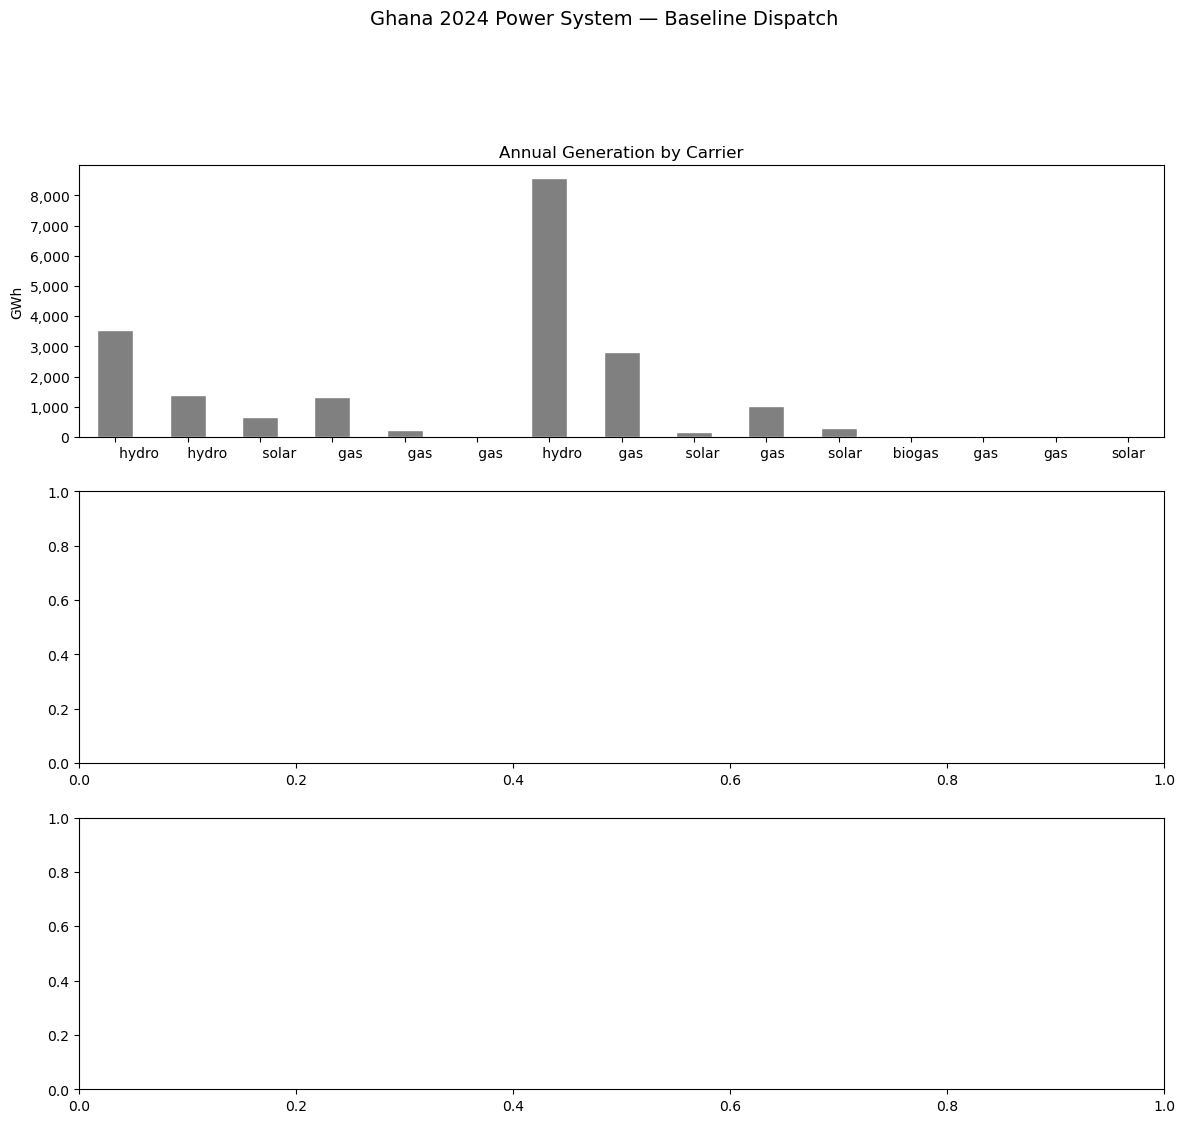

In [18]:
# ── 8. PLOTS ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 12))
fig.suptitle("Ghana 2024 Power System — Baseline Dispatch", fontsize=14, y=1.01)
 
# Plot 1: Annual generation mix (bar)
ax = axes[0]
colors = {"hydro": "#2196F3", "solar": "#FFC107", "gas": "#FF5722", "biogas": "#4CAF50"}
gen_by_carrier.plot(
    kind="bar", ax=ax,
    color=[colors.get(c, "grey") for c in gen_by_carrier.index],
    edgecolor="white"
)
ax.set_title("Annual Generation by Carrier")
ax.set_ylabel("GWh")
ax.set_xlabel("")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.tick_params(axis="x", rotation=0)

In [19]:
# Plot 2: Weekly dispatch sample (first 2 weeks of January)
ax = axes[1]
sample = n.generators_t.p.iloc[:336]   # 2 weeks
carrier_dispatch = sample.T.groupby(n.generators.carrier).sum().T / 1000  # GW
carrier_dispatch.plot.area(
    ax=ax, stacked=True,
    color=[colors.get(c, "grey") for c in carrier_dispatch.columns],
    alpha=0.85, linewidth=0
)
ax.plot(
    sample.index,
    n.loads_t.p["Ghana_load"].iloc[:336] / 1000,
    color="black", linewidth=1.2, linestyle="--", label="Demand"
)
ax.set_title("Dispatch — First Two Weeks of January 2024")
ax.set_ylabel("GW")
ax.legend(loc="upper right", fontsize=8)

In [20]:
# Plot 3: Duration curve
ax = axes[2]
sorted_load = total_load.sort_values(ascending=False).values / 1000
ax.plot(sorted_load, color="#1A237E", linewidth=1.5)
ax.fill_between(range(len(sorted_load)), sorted_load, alpha=0.15, color="#1A237E")
ax.set_title("Load Duration Curve 2024")
ax.set_xlabel("Hours")
ax.set_ylabel("GW")
ax.axhline(y=sorted_load.mean(), color="red", linestyle="--",
           linewidth=1, label=f"Mean {sorted_load.mean():.2f} GW")
ax.legend()
 
plt.tight_layout()
plt.savefig(f"{RESULTS_PATH}baseline_2024.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\nPlot saved to {RESULTS_PATH}baseline_2024.png")
 
# ── 9. SAVE RESULTS ────────────────────────────────────────────────────────
# Hourly dispatch
n.generators_t.p.to_csv(f"{RESULTS_PATH}dispatch_2024.csv")
 
# Summary table
summary = pd.DataFrame({
    "generation_GWh": gen_by_carrier,
    "share_pct":      gen_by_carrier / total_gen * 100,
})
summary.to_csv(f"{RESULTS_PATH}generation_summary_2024.csv")
 
print(f"Results saved to {RESULTS_PATH}")
print("\nBaseline complete.")

<Figure size 640x480 with 0 Axes>


Plot saved to /data/Pypsa-Research/results/baseline_2024.png
Results saved to /data/Pypsa-Research/results/

Baseline complete.
